In [2]:
import pandas as pd
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt

Content
Columns

age: age of primary beneficiary

sex: insurance contractor gender, female, male

bmi: Body mass index, providing an understanding of body, weights that are relatively high or low relative to height,
objective index of body weight (kg / m ^ 2) using the ratio of height to weight, ideally 18.5 to 24.9

children: Number of children covered by health insurance / Number of dependents

smoker: Smoking

region: the beneficiary's residential area in the US, northeast, southeast, southwest, northwest.

charges: Individual medical costs billed by health insurance

In [3]:
df = pd.read_csv(r"C:\Users\91972\Downloads\archive (17)\insurance.csv")

df.info()
df.sample(3)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,sex,bmi,children,smoker,region,charges
16,52,female,30.78,1,no,northeast,10797.3362
766,47,male,32.30,1,no,southwest,8062.7640
1333,50,male,30.97,3,no,northwest,10600.5483


In [4]:
# Analysing data
print(np.round(df[(df['sex'] == 'female') & (df['children'] == 0)].groupby(['region','sex','smoker','children'])['charges'].agg(['count','min','max']),2))
np.round(df.groupby(['region','sex','smoker'])['charges'].agg(['count','min','max']),2)

                                  count       min       max
region    sex    smoker children                           
northeast female no     0            65   2196.47  25656.58
                 yes    0             7  14283.46  42111.66
northwest female no     0            55   2117.34  28923.14
                 yes    0            17  14711.74  55135.40
southeast female no     0            57   1607.51  27117.99
                 yes    0            19  16577.78  63770.43
southwest female no     0            59   1727.78  18955.22
                 yes    0            10  13844.51  48824.45


count       min       max
region    sex    smoker                           
northeast female no        132   2196.47  31620.00
                 yes        29  14283.46  58571.07
          male   no        125   1694.80  32108.66
                 yes        38  12829.46  48549.18
northwest female no        135   2117.34  33471.97
                 yes        29  14711.74  55135.40
          male   no        132   1621.34  30284.64
                 yes        29  15817.99  60021.40
southeast female no        139   1607.51  36580.28
                 yes        36  16577.78  63770.43
          male   no        134   1121.87  27724.29
                 yes        55  17043.34  62592.87
southwest female no        141   1727.78  36910.61
                 yes        21  13844.51  48824.45
          male   no        126   1241.56  27941.29
                 yes        37  15820.70  52590.83

               age       bmi  children   charges
age       1.000000  0.109272  0.042469  0.299008
bmi       0.109272  1.000000  0.012759  0.198341
children  0.042469  0.012759  1.000000  0.067998
charges   0.299008  0.198341  0.067998  1.000000


<Axes: >

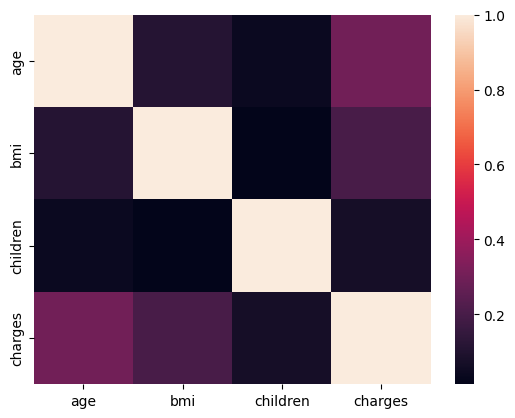

In [5]:
corr = df.drop(['sex','smoker','region'],axis=1).corr()
print(corr)
sns.heatmap(corr)

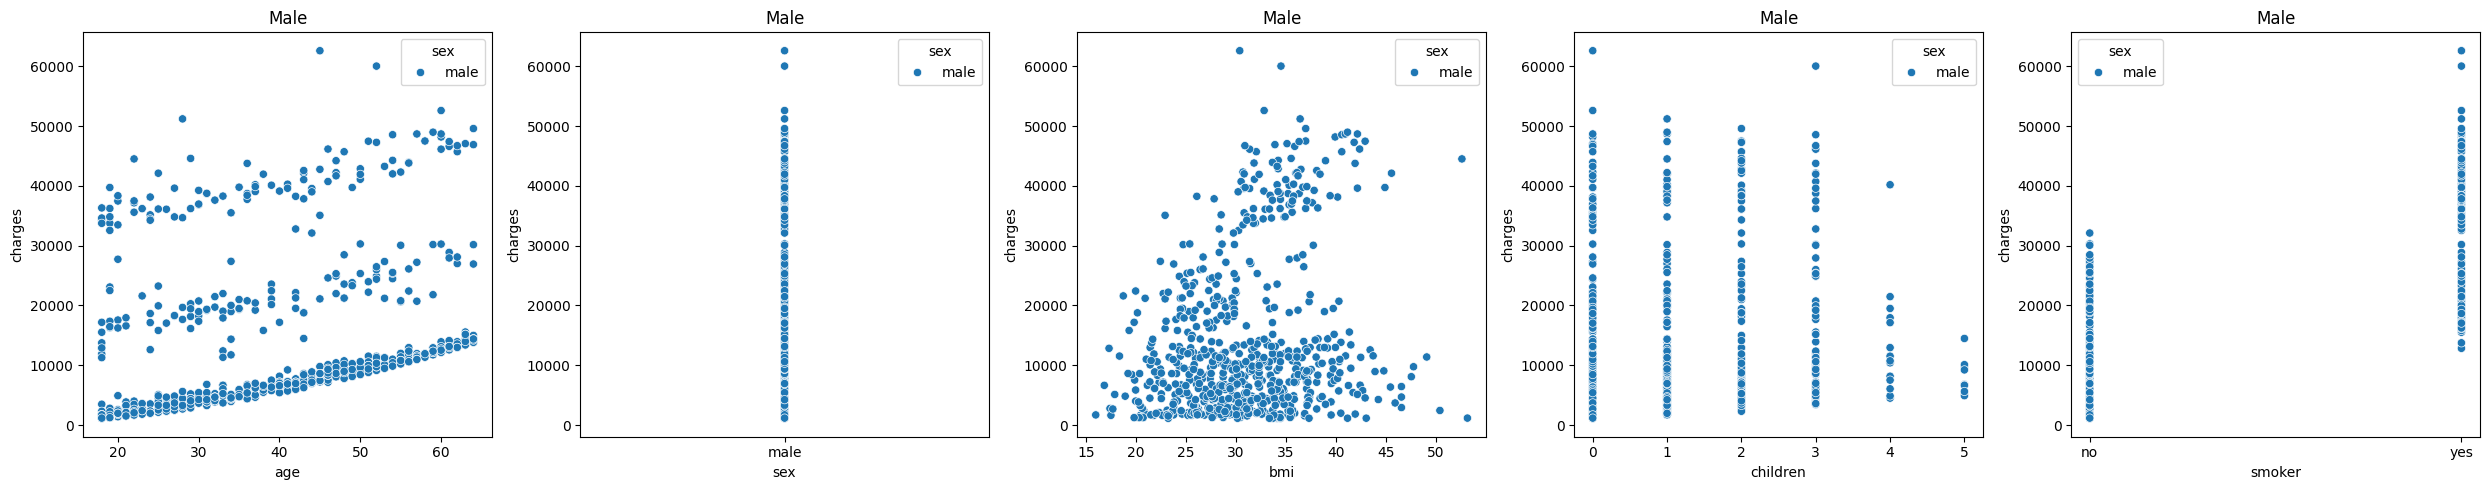

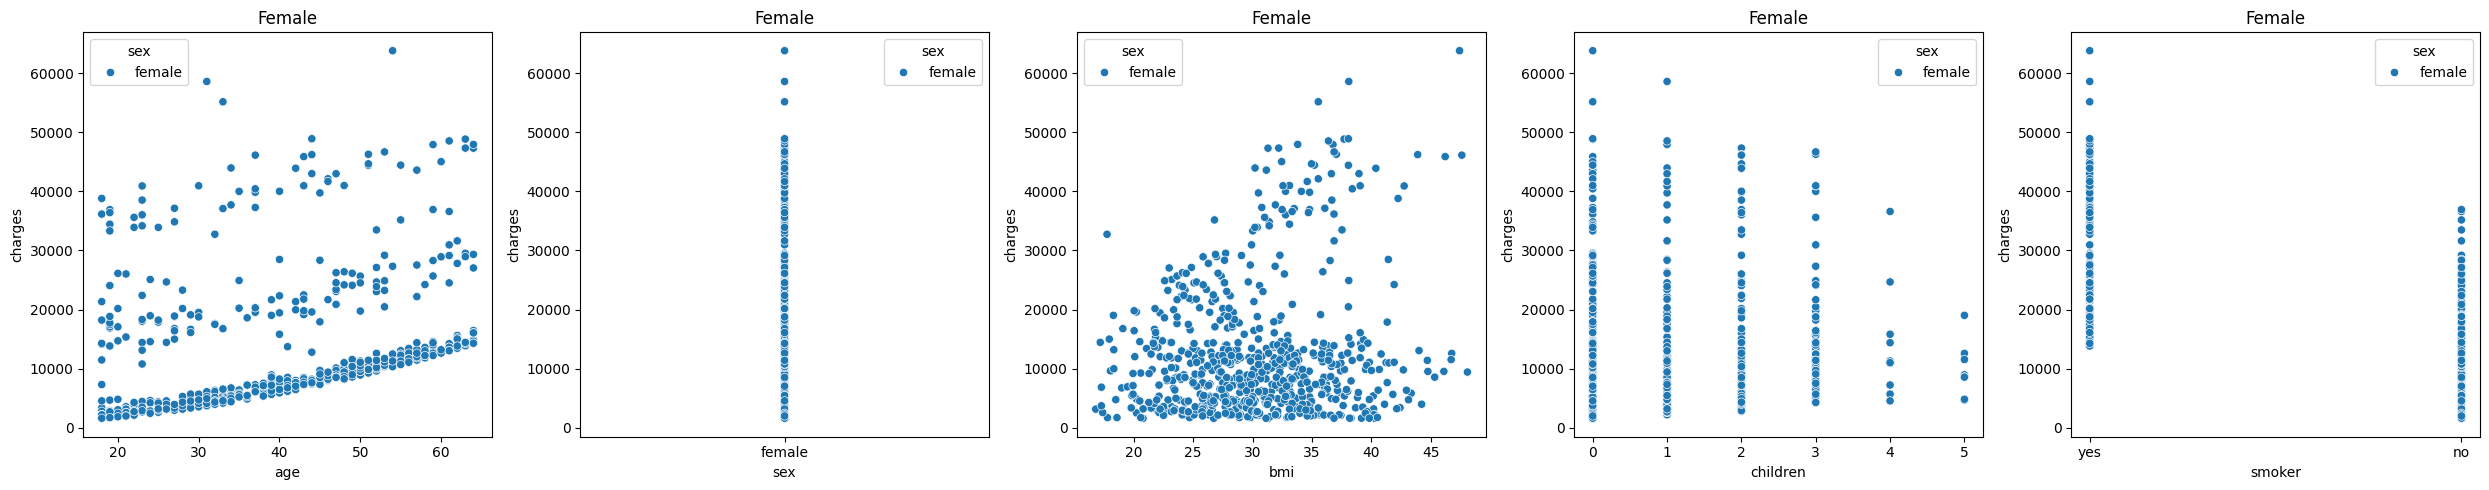

In [6]:
# plot of each feature with other features and each featture with target
plt.figure(figsize=(25,5))
for i in range(len(df.drop(['sex','charges'],axis=1).columns)):
    plt.subplot(1,5,i+1)
    sns.scatterplot(y=df[df['sex']=='male']['charges'],x=df[df['sex']=='male'].iloc[:,i],hue=df[df['sex']=='male']['sex'])
    plt.title('Male')
   
plt.tight_layout()
plt.show()

plt.figure(figsize=(25,5))    
for i in range(len(df.drop(['sex','charges'],axis=1).columns)):
    plt.subplot(1,5,i+1)
    sns.scatterplot(y=df[df['sex']=='female']['charges'],x=df[df['sex']=='female'].iloc[:,i],hue=df[df['sex']=='female']['sex'])
    plt.title('Female')
plt.tight_layout()
plt.show()

# From the followung scatter with charges on y axis we can see that the charges increase with age , smoking


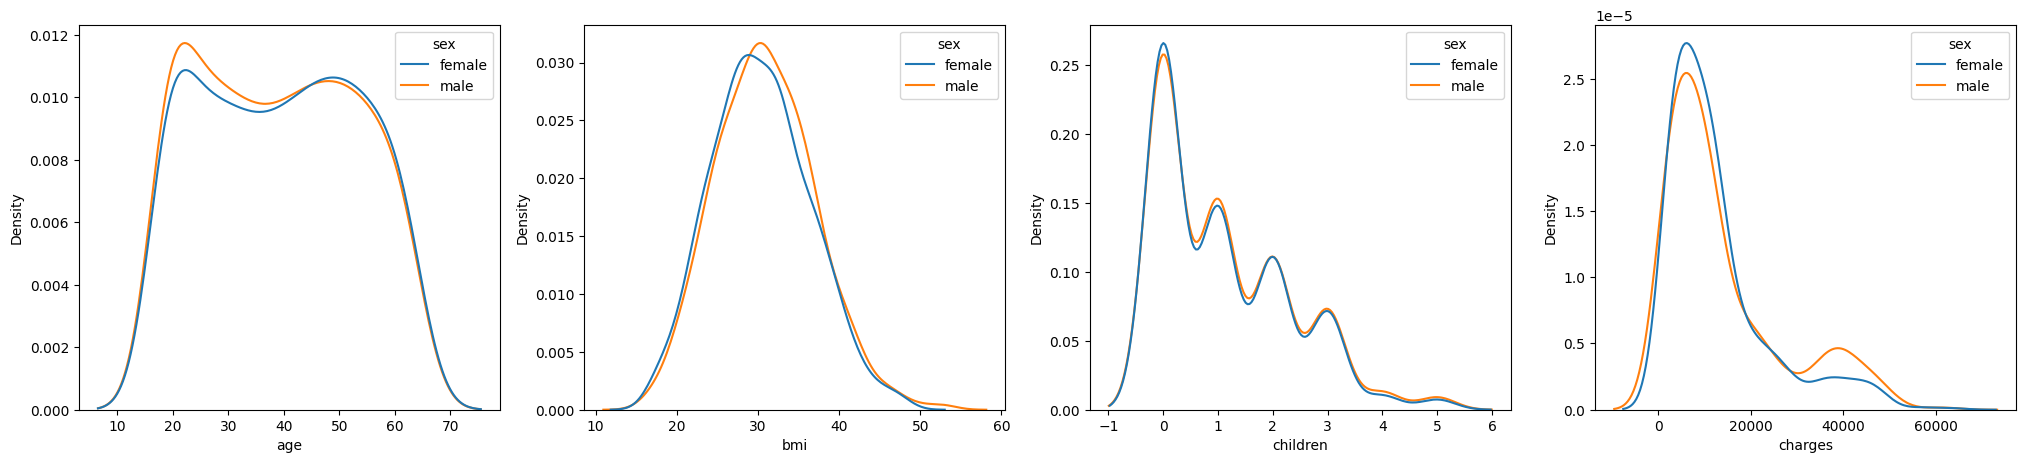

In [7]:
# Checking distributions of columns
col = df.drop(['sex','smoker','region'],axis=1).columns
# col[0]
plt.figure(figsize=(25,5))
for i in range(len(col)):
    plt.subplot(1,len(col),i+1)
    sns.kdeplot(data =df ,x=col[i],hue='sex')


# From here we can see the age column is likely bo to normally distributed why the bmi is .

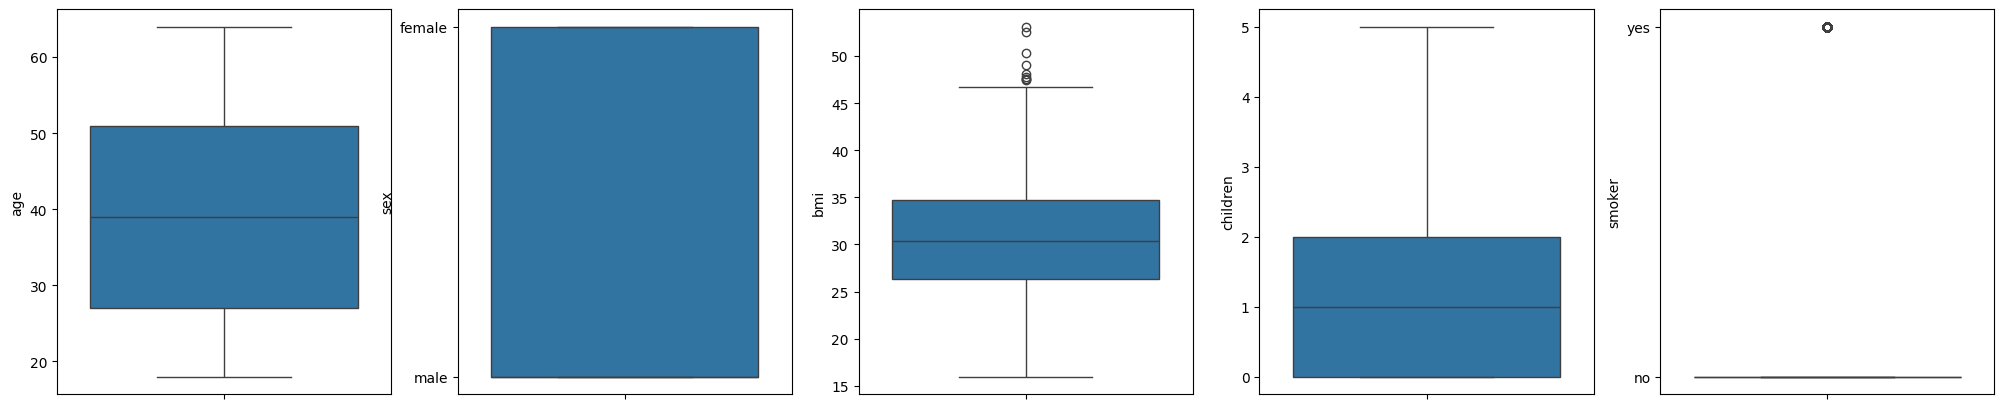

In [8]:
# Detection of outliars
plt.figure(figsize=(25,5))   
for i in range(len(df.drop(['sex','charges'],axis=1).columns)):
    plt.subplot(1,5,i+1)
    sns.boxplot(df.iloc[:,i])

# BMI feature has outliars

In [9]:
# Removing outliars (capping) of BMI feature

l = (df['bmi'].mean() - 3*df['bmi'].std()) 
u = (df['bmi'].mean() + 3*df['bmi'].std()) 

# Obtaining index of outliars
df['bmi'][(df['bmi'] <= l) | (df['bmi'] >= u)]

# capping them
df[['bmi']] = df[['bmi']].clip(l,u)

# visuaizing
df['bmi'][(df['bmi'] <= l) | (df['bmi'] >= u)]

116     48.957958
847     48.957958
1047    48.957958
1317    48.957958
Name: bmi, dtype: float64

In [10]:
colm = df.columns
print(colm)
cat_col = colm[[1,4,5]]
num_col = colm[[0,2,3,6]]


Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')


# Starting ML - Regression

In [11]:
from sklearn.model_selection import train_test_split

X_train , X_test ,y_train , y_test = train_test_split(df.drop('charges',axis=1),df['charges'],test_size=0.2,random_state=90)

In [12]:
# Models
from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet

## SIMPLE LR

In [94]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler,PolynomialFeatures,PowerTransformer

ct1 = ColumnTransformer(transformers=[('encoding',OneHotEncoder(drop='first'),cat_col)],
                       remainder='passthrough')

from sklearn.pipeline import Pipeline
lr = LinearRegression()

pipe1=Pipeline(steps=[
    ('enc',ct1),
    ('m1',lr)
])

pipe1.fit(X_train,y_train)

print(f'{pipe1.score(X_train,y_train)},\n coefficents \n{pipe1[1].intercept_},\n{pipe1[1].coef_}')

0.7513729356955662,
 coefficents 
-11743.907743711388,
[ -118.98897289 24101.51830894  -387.72255754 -1089.42981176
 -1348.90405722   252.72989303   343.1359369    509.55283133]


In [14]:

pipe1

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('enc', ...), ('m1', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('encoding', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse 

## Elasic Net

In [15]:
en = ElasticNet(max_iter=10000)

pipe2nd=Pipeline(steps=[
    ('enc',ct1),
    ('m2',en)
])

from sklearn.model_selection import GridSearchCV

param_grid = {
    'm2__l1_ratio':[0,0.2,0.8,1],
    'm2__alpha':[1.2,1.5,1.8,2.2]
}

gcv = GridSearchCV(param_grid=param_grid,cv=5,estimator=pipe2nd)
gcv.fit(X_train,y_train)


C:\Users\91972\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.031e+10, tolerance: 1.246e+07
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
C:\Users\91972\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.918e+10, tolerance: 1.227e+07
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV 

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...iter=10000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'m2__alpha': [1.2, 1.5, ...], 'm2__l1_ratio': [0, 0.2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;-

In [89]:
pipe2 = gcv.best_estimator_

pipe2.fit(X_train,y_train)
print(f'{pipe2.score(X_train,y_train)},\n coefficents \n{pipe2[1].intercept_},\n{pipe2[1].coef_}')
pipe2

0.7513708328190322,
 coefficents 
-11761.01513384248,
[ -109.12157083 24087.05458477  -349.86618045 -1049.8862775
 -1310.51987106   252.76376363   342.68390766   507.65311856]


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('enc', ...), ('m2', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('encoding', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse 

## Elastic Net with Polynomials

In [17]:
en = ElasticNet(max_iter=100000)

pipe3rd=Pipeline(steps=[
    ('enc',ct1),
    ('poly',PolynomialFeatures(2)),
    ('sd',StandardScaler()),
    ('m3',en)
])

from sklearn.model_selection import GridSearchCV

param_grid = {
    'm3__l1_ratio':[0,0.8,1],
    'm3__alpha':[1.5,1.8,2.5,3],
    'poly__include_bias':[True,False]
}

gcv0 = GridSearchCV(param_grid=param_grid,cv=5,estimator=pipe3rd)
gcv0.fit(X_train,y_train)




C:\Users\91972\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.539e+10, tolerance: 1.246e+07
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
C:\Users\91972\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.551e+10, tolerance: 1.227e+07
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV 

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ter=100000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'m3__alpha': [1.5, 1.8, ...], 'm3__l1_ratio': [0, 0.8, ...], 'poly__include_bias': [True, False]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed

In [90]:
pipe3 = gcv0.best_estimator_
pipe3.fit(X_train,y_train)
print(f'{pipe3.score(X_train,y_train)},\n coefficents \n{pipe3[3].intercept_},\n{pipe3[3].coef_}')
pipe3

0.8468935473046245,
 coefficents 
13417.61110938223,
[    0.          -429.82056892 -8169.08124326   -27.84612867
  1083.81896034   447.17133044 -1285.16816593  1945.03822346
  1694.43513276    -0.           -82.2058092   -120.90222716
    -0.          -228.9178142    263.55582097   325.14465399
  -334.94289912    -0.           -24.89057501  -291.53161615
   197.5016422    -96.74031903 18839.90564772  -327.44789671
  -179.11811245     0.             0.            -0.
     0.           152.76859742     0.             0.
  1064.60581335 -2493.3778253   -163.44860402    61.94856959
   439.0860021  -1153.66407551  -525.6561591   4650.84053659
    -0.          -306.82658924 -1599.0102718    206.07553345
  -261.36677148]


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('enc', ...), ('poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('encoding', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

# Decision Trees

In [19]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=45)

pipe4th=Pipeline(steps=[
    ('enc',ct1),
    ('poly',PolynomialFeatures()),
    ('sd',StandardScaler()),
    ('m4',dt)
])

from sklearn.model_selection import GridSearchCV

param_grid = {
    'poly__include_bias':[True,False],
    'poly__degree':[1,2],
    'm4__max_depth':[2,3,4,5,6,7],
    'm4__min_samples_leaf':[20,30,40],
    'm4__min_samples_split':[70,90,120,150],
}

gcv1 = GridSearchCV(param_grid=param_grid,cv=5,estimator=pipe4th)
gcv1.fit(X_train,y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=45))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'m4__max_depth': [2, 3, ...], 'm4__min_samples_leaf': [20, 30, ...], 'm4__min_samples_split': [70, 90, ...], 'poly__degree': [1, 2], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each f

In [91]:
pipe4 = gcv1.best_estimator_
pipe4.fit(X_train,y_train)
print(f'{pipe4.score(X_train,y_train)}')
pipe4
gcv1.best_params_

0.8670433884127282


{'m4__max_depth': 5,
 'm4__min_samples_leaf': 30,
 'm4__min_samples_split': 70,
 'poly__degree': 1,
 'poly__include_bias': True}

# Random Forest

In [21]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=45,oob_score=True)
ct1 = ColumnTransformer(transformers=[('encoding',OneHotEncoder(drop='first'),cat_col)],
                       remainder='passthrough')
pipe5th=Pipeline(steps=[
    ('enc',ct1),
    ('poly',PolynomialFeatures(include_bias=True,degree=1)),
    ('sd',StandardScaler()),
    ('m5',rf)
])

from sklearn.model_selection import GridSearchCV

param_grid = {
    'm5__max_depth':[2,3,4,5,6,7],
    'm5__min_samples_leaf':[20,30,40],
    'm5__min_samples_split':[70,90,120,150],
    'poly__degree' :[1,2]
}

gcv2 = GridSearchCV(param_grid=param_grid,cv=5,estimator=pipe5th)
gcv2.fit(X_train,y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=45))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'m5__max_depth': [2, 3, ...], 'm5__min_samples_leaf': [20, 30, ...], 'm5__min_samples_split': [70, 90, ...], 'poly__degree': [1, 2]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold a

In [87]:
pipe5 = gcv2.best_estimator_
pipe5.fit(X_train,y_train)
print(f'{pipe5.score(X_train,y_train)}')
pipe5[3].oob_score_
pipe5
gcv2.best_params_


0.8618181635254127


{'m5__max_depth': 5,
 'm5__min_samples_leaf': 30,
 'm5__min_samples_split': 70,
 'poly__degree': 1}

In [95]:
print(f'm1:{pipe1.score(X_train,y_train)},\nm2:{pipe2.score(X_train,y_train)},\nm3:{pipe3.score(X_train,y_train)},\nm4:{pipe4.score(X_train,y_train)},\nm5:{pipe5.score(X_train,y_train)}')

m1:0.7513729356955662,
m2:0.7513708328190322,
m3:0.8468935473046245,
m4:0.8670433884127282,
m5:0.8618181635254127


In [96]:
print(f'm1:{pipe1.score(X_test,y_test)},\nm2:{pipe2.score(X_test,y_test)},\nm3:{pipe3.score(X_test,y_test)},\nm4:{pipe4.score(X_test,y_test)},\nm5:{pipe5.score(X_test,y_test)}')

m1:0.7459239498191239,
m2:0.7460572788465798,
m3:0.8488122177411068,
m4:0.8537345153392542,
m5:0.859485816700263


In [25]:
print('Best Model is pipe5')

Best Model is pipe5


<Axes: >

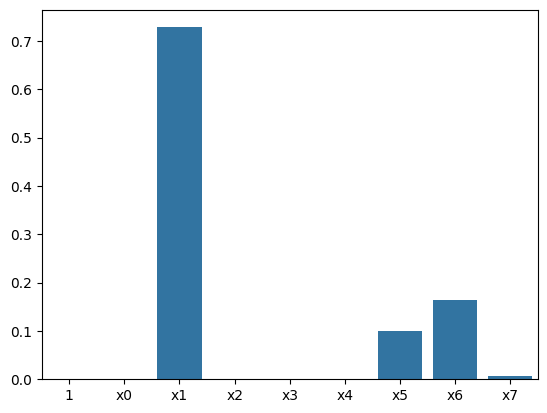

In [26]:
# observing feature importance
fi = pipe5['m5'].feature_importances_
fn =pipe5['poly'].get_feature_names_out()
pipe5['enc'].get_feature_names_out()
sns.barplot(x=fn,y=fi)

In [97]:
s1 = pipe5[0]
s2 = pipe5[1]
s3 = pipe5[2]
s4 = pipe5[3]
print(s1.get_feature_names_out(),len(s1.get_feature_names_out()))
print(s2.get_feature_names_out(),len(s2.get_feature_names_out()))
print(s3.get_feature_names_out(),len(s3.get_feature_names_out()))

['encoding__sex_male' 'encoding__smoker_yes' 'encoding__region_northwest'
 'encoding__region_southeast' 'encoding__region_southwest'
 'remainder__age' 'remainder__bmi' 'remainder__children'] 8
['1' 'x0' 'x1' 'x2' 'x3' 'x4' 'x5' 'x6' 'x7'] 9
['x0' 'x1' 'x2' 'x3' 'x4' 'x5' 'x6' 'x7' 'x8'] 9


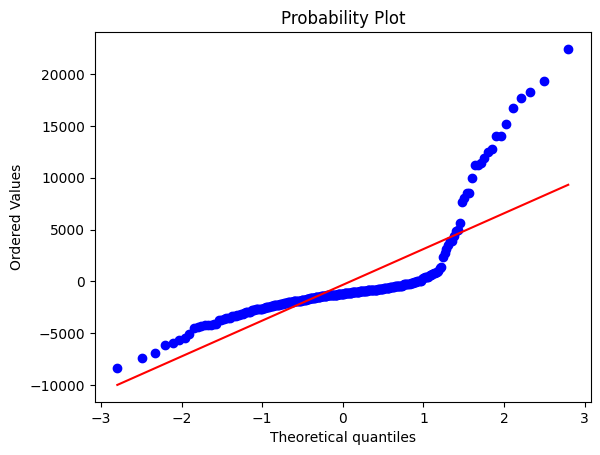

In [100]:
# plotting residual plot ( checking normality of residual)
re = (y_test.values - pipe5.predict(X_test))S
# sns.scatterplot(x=pipe5.predict(X_test),y=re)

import scipy.stats as st 
st.probplot(re,plot=plt)
plt.show()


<Axes: xlabel='charges', ylabel='Density'>

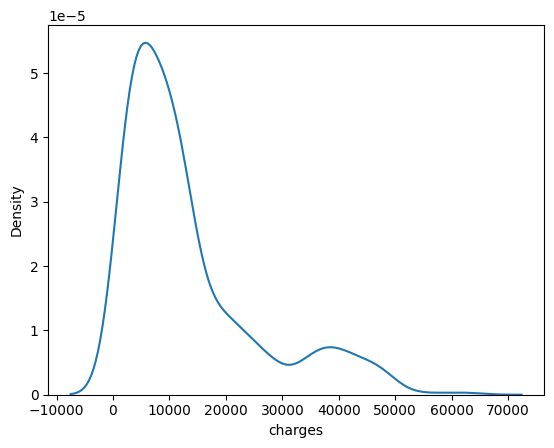

In [101]:
sns.kdeplot(df['charges'])

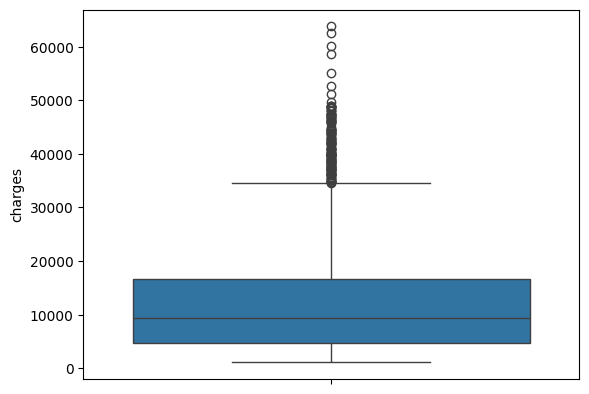

np.int64(169)

In [64]:
# Corrected syntax:
df2[((df2['charges'] > u) | (df2['charges'] < l)) & (df2['smoker'] == 'yes')]

,age,sex,bmi,children,smoker,region,charges
14,27,male,42.13,0,yes,southeast,39611.7577
19,30,male,35.30,0,yes,southwest,36837.4670
23,34,female,31.92,1,yes,northeast,37701.8768
29,31,male,36.30,2,yes,southwest,38711.0000
30,22,male,35.60,0,yes,southwest,35585.5760
...,...,...,...,...,...,...,...
1303,43,male,27.80,0,yes,southwest,37829.7242
1308,25,female,30.20,0,yes,southwest,33900.6530
1313,19,female,34.70,2,yes,southwest,36397.5760
1323,42,female,40.37,2,yes,southeast,43896.3763


In [57]:
df2

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# fitting model 6 with regression forest and polynomial features degree = 2 to make residual normal
## but nothing happens

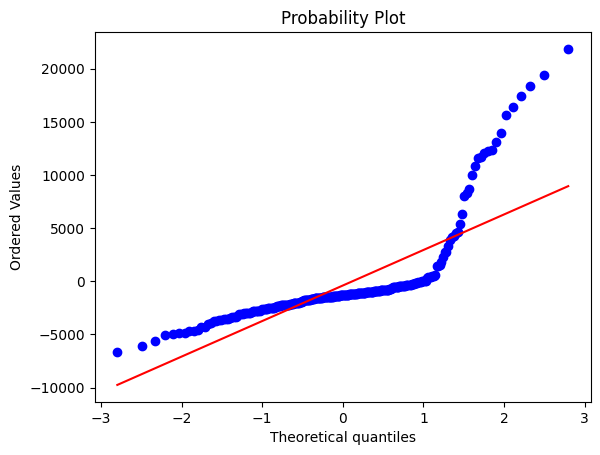

In [103]:
from sklearn.model_selection import train_test_split

X_traiin , X_testt ,y_traiin , y_testt = train_test_split(df.drop('charges',axis=1),df['charges'],test_size=0.2,random_state=90)

pipe6=Pipeline(steps=[
    ('enc',ct1),
    ('poly',PolynomialFeatures(include_bias=True,degree=2)),
    ('sd',StandardScaler()),
    ('m5',RandomForestRegressor(max_depth=5,min_samples_leaf=30 , min_samples_split=70))
])
pipe6.fit(X_traiin,y_traiin)
pipe6.score(X_traiin,y_traiin)
np.sqrt(mean_squared_error(y_testt,pipe6.predict(X_testt)))
re = y_testt - pipe6.predict(X_testt)
# sns.kdeplot(re)
st.probplot(re,plot=plt)
plt.show()


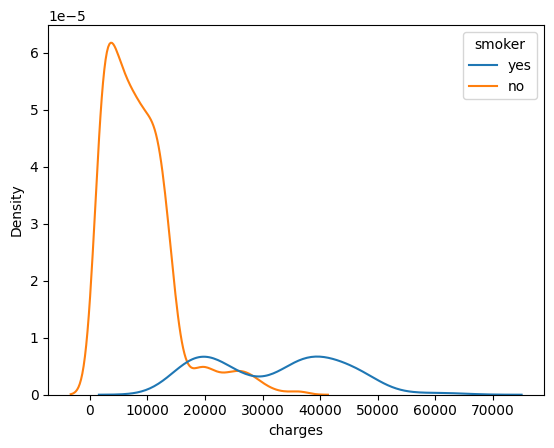

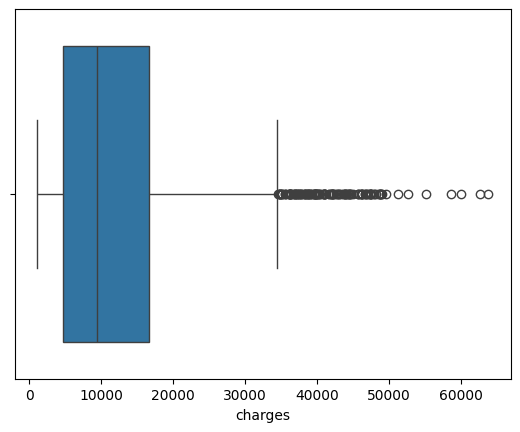

np.int64(157)

In [113]:
sns.kdeplot(data=df2, x='charges', hue='smoker')
plt.show()



df2 = df.copy()
sns.boxplot(data=df2, x='charges')
plt.show()
q1=st.quantile(df2['charges'],0.25)
q3=st.quantile(df2['charges'],0.75)
iqr = q3-q1
l = q1 - iqr
u = q3 + iqr
# df2['charges'] = df['charges'].clip(l,u)
((df2['charges'] > u ) | (df2['charges'] < l )).sum()
# sns.boxplot(df2['charges'])
df['charges'][((df2['charges'] > u ) | (df2['charges'] < l )) & (df2['smoker'] == 'yes' )].count()

In [114]:

print(f'm1:{np.sqrt(mean_squared_error(pipe1.predict(X_test),y_test)),},\nm2:{np.sqrt(mean_squared_error(pipe2.predict(X_test),y_test))},\nm3:{np.sqrt(mean_squared_error(pipe3.predict(X_test),y_test))},\nm4:{np.sqrt(mean_squared_error(pipe4.predict(X_test),y_test))},\nm5:{np.sqrt(mean_squared_error(pipe5.predict(X_test),y_test))},\nm6:{np.sqrt(mean_squared_error(pipe6.predict(X_testt),y_testt))}')

m1:(np.float64(5751.682395363708),),
m2:5750.173070004022,
m3:4436.815609161518,
m4:4363.992134431081,
m5:4277.333504803489,
m6:4214.871389161911


In [115]:
from sklearn.metrics import mean_squared_error

print(f'm1:{np.sqrt(mean_squared_error(pipe1.predict(X_train),y_train)),},\nm2:{np.sqrt(mean_squared_error(pipe2.predict(X_train),y_train))},\nm3:{np.sqrt(mean_squared_error(pipe3.predict(X_train),y_train))},\nm4:{np.sqrt(mean_squared_error(pipe4.predict(X_train),y_train))},\nm5:{np.sqrt(mean_squared_error(pipe5.predict(X_train),y_train))},\nm6:{np.sqrt(mean_squared_error(pipe6.predict(X_traiin),y_traiin))}')

m1:(np.float64(6117.600571622393),),
m2:6117.626442763012,
m3:4800.690014145019,
m4:4473.648788109236,
m5:4560.709360254335,
m6:4515.749572511715


In [116]:
from sklearn.model_selection import cross_val_score
cv_results = cross_val_score(pipe6, X_traiin, y_traiin, cv=5, scoring='r2')

print(f"CV Scores: {cv_results}")
print(f"Mean R2: {cv_results.mean():.4f}")
print(f"Standard Deviation: {cv_results.std():.4f}")

CV Scores: [0.84056812 0.86649041 0.80822514 0.83876265 0.82164953]
Mean R2: 0.8351
Standard Deviation: 0.0197
